<a href="https://colab.research.google.com/github/Yeabebe/MCTS/blob/main/MCTS_TicTacToe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports and Configuration

In [25]:
import math
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


SEED = 42
random.seed(SEED)
np.random.seed(SEED)

Tic-Tac-Toe Environment

In [26]:
class TicTacToe:
    def __init__(self):
        self.reset()

    def reset(self):
        self.board = np.zeros(9, dtype=np.int8)
        self.player = 1
        return self

    def copy(self):
        game = TicTacToe()
        game.board = self.board.copy()
        game.player = self.player
        return game

    def legal_moves(self):
        return np.flatnonzero(self.board == 0).tolist()

    def make_move(self, move):
        if self.board[move] != 0:
            raise ValueError("Illegal move")

        self.board[move] = self.player
        self.player *= -1

    def winner(self):
        lines = [
            (0, 1, 2), (3, 4, 5), (6, 7, 8),
            (0, 3, 6), (1, 4, 7), (2, 5, 8),
            (0, 4, 8), (2, 4, 6)
        ]

        for a, b, c in lines:
            total = self.board[a] + self.board[b] + self.board[c]

            if total == 3:
                return 1
            if total == -3:
                return -1

        return 0

    def terminal(self):
        return self.winner() != 0 or not np.any(self.board == 0)

    def result(self):
        winner = self.winner()

        if winner != 0:
            return winner

        if not np.any(self.board == 0):
            return 0

        return None

    def render(self):
        symbols = {1: "X", -1: "O", 0: " "}

        for r in range(3):
            print(
                f" {symbols[self.board[3*r]]} |"
                f" {symbols[self.board[3*r+1]]} |"
                f" {symbols[self.board[3*r+2]]}"
            )
            if r < 2:
                print("---+---+---")

    def key(self):
        return tuple(self.board) + (self.player,)

Environment Test

In [27]:
game = TicTacToe()

print("Initial board:")
game.render()

print("\nLegal moves:", game.legal_moves())
print("Current player:", "X" if game.player == 1 else "O")
print("Terminal:", game.terminal())

Initial board:
   |   |  
---+---+---
   |   |  
---+---+---
   |   |  

Legal moves: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Current player: X
Terminal: False


MCTS Node

In [28]:
class Node:
    def __init__(self, state, parent=None, move=None):
        self.state = state
        self.parent = parent
        self.move = move

        self.children = {}
        self.untried = state.legal_moves()

        self.visits = 0
        self.value = 0.0

    @property
    def q(self):
        return self.value / self.visits if self.visits else 0.0

    @property
    def fully_expanded(self):
        return len(self.untried) == 0

UCT

In [29]:
def uct(child, parent, c=math.sqrt(2)):
    if child.visits == 0:
        return float("inf")

    exploitation = child.q
    exploration = c * math.sqrt(
        math.log(parent.visits) / child.visits
    )

    return exploitation + exploration

Pure MCTS

In [55]:
class MCTS:
    def __init__(self, simulations=1000, c=math.sqrt(2)):
        self.simulations = simulations
        self.c = c

    def select(self, node):
        while node.fully_expanded and not node.state.terminal():
            node = max(
                node.children.values(),
                key=lambda child: uct(child, node, self.c)
            )
        return node

    def expand(self, node):
        move = random.choice(node.untried)
        node.untried.remove(move)

        state = node.state.copy()
        state.make_move(move)

        child = Node(state, node, move)
        node.children[move] = child

        return child

    def rollout(self, state, root_player):
        state = state.copy()

        while not state.terminal():
            move = random.choice(state.legal_moves())
            state.make_move(move)

        winner = state.result()

        if winner == 0:
            return 0

        return 1 if winner == root_player else -1

    def backpropagate(self, node, result):
        while node is not None:
            node.visits += 1
            node.value += result

            # Negamax perspective:
            # switch value when moving to opponent's node.
            result = -result
            node = node.parent

    def search(self, state):
        root = Node(state.copy())

        # Player at the root of the search
        root_player = state.player

        for _ in range(self.simulations):
            node = self.select(root)

            if not node.state.terminal():
                node = self.expand(node)

            result = self.rollout(node.state, root_player)
            self.backpropagate(node, result)

        return root

    def choose_move(self, state):
        root = self.search(state)

        return max(
            root.children.values(),
            key=lambda child: child.visits
        ).move

Test Pure MCTS

In [56]:
game = TicTacToe()

mcts = MCTS(simulations=1000)

move = mcts.choose_move(game)

print("Selected move:", move)

Selected move: 7


Inspect Search Statistics

In [57]:
root = mcts.search(TicTacToe())

stats = []

for move, child in root.children.items():
    stats.append({
        "Move": move,
        "Visits": child.visits,
        "Value": round(child.value, 2),
        "Q": round(child.q, 4)
    })

pd.DataFrame(stats).sort_values(
    "Visits",
    ascending=False
)

,Move,Visits,Value,Q
2,2,153,6.0,0.0392
4,0,131,2.0,0.0153
8,5,130,2.0,0.0154
5,7,117,5.0,0.0427
6,4,106,-2.0,-0.0189
0,1,100,-3.0,-0.0300
3,3,98,-4.0,-0.0408
1,6,92,-5.0,-0.0543
7,8,73,-7.0,-0.0959


Search Tree Visualization

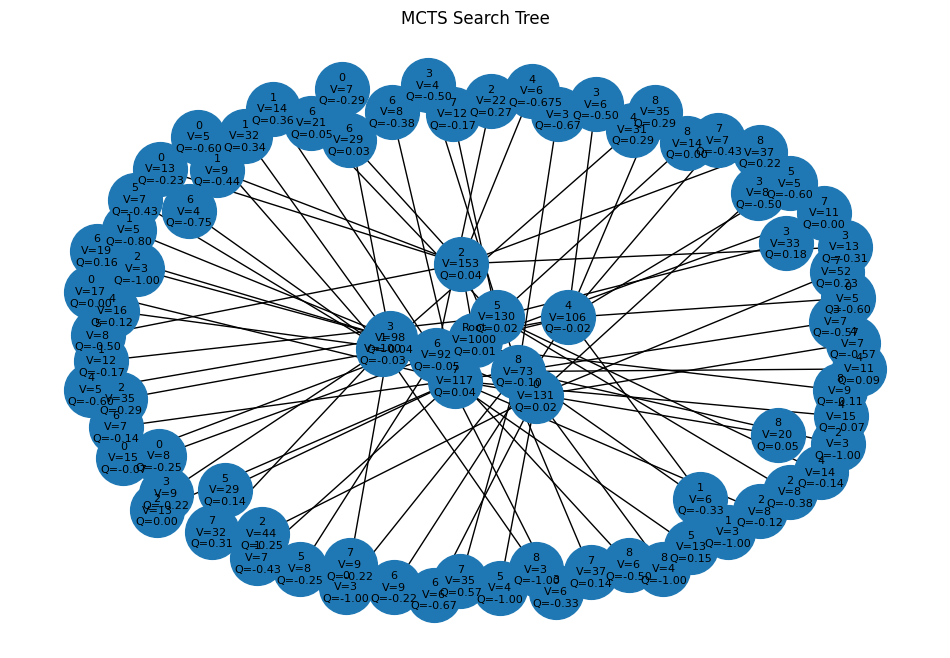

In [58]:
def build_tree_graph(node, graph=None, parent=None, depth=0, max_depth=2):
    if graph is None:
        graph = nx.DiGraph()

    node_id = id(node)

    label = f"{node.move if node.move is not None else 'Root'}\nV={node.visits}\nQ={node.q:.2f}"
    graph.add_node(node_id, label=label)

    if parent is not None:
        graph.add_edge(parent, node_id)

    if depth < max_depth:
        for child in node.children.values():
            build_tree_graph(child, graph, node_id, depth + 1, max_depth)

    return graph

graph = build_tree_graph(root)

plt.figure(figsize=(12,8))

pos = nx.spring_layout(graph, seed=42)

nx.draw_networkx_nodes(graph, pos, node_size=1500)
nx.draw_networkx_edges(graph, pos)
nx.draw_networkx_labels(
    graph,
    pos,
    labels=nx.get_node_attributes(graph, "label"),
    font_size=8
)

plt.title("MCTS Search Tree")
plt.axis("off")
plt.show()

Visit Heatmap

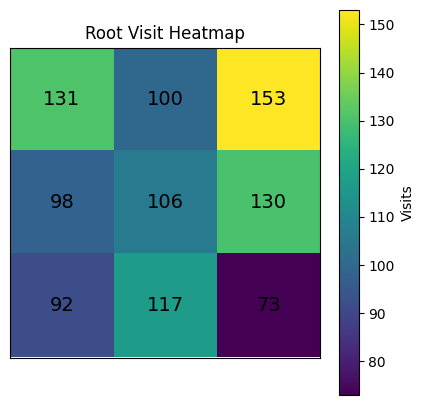

In [59]:
visit_grid = np.zeros(9)

for move, child in root.children.items():
    visit_grid[move] = child.visits

visit_grid = visit_grid.reshape(3,3)

plt.figure(figsize=(5,5))

plt.imshow(visit_grid)

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            int(visit_grid[i,j]),
            ha="center",
            va="center",
            fontsize=14
        )

plt.xticks([])
plt.yticks([])
plt.title("Root Visit Heatmap")
plt.colorbar(label="Visits")
plt.show()

Random Agent

In [60]:
class RandomAgent:
    def choose_move(self, state):
        return random.choice(state.legal_moves())

Game Runner

In [61]:
def play_game(x_agent, o_agent, verbose=False):
    game = TicTacToe()

    agents = {
        1: x_agent,
        -1: o_agent
    }

    while not game.terminal():
        player = game.player
        move = agents[player].choose_move(game.copy())

        game.make_move(move)

        if verbose:
            print()
            game.render()

    return game.result()

MCTS vs Random

In [62]:
mcts_agent = MCTS(simulations=500)
random_agent = RandomAgent()

result = play_game(
    mcts_agent,
    random_agent,
    verbose=True
)

print("\nResult:", result)


   |   | X
---+---+---
   |   |  
---+---+---
   |   |  

 O |   | X
---+---+---
   |   |  
---+---+---
   |   |  

 O |   | X
---+---+---
   |   | X
---+---+---
   |   |  

 O |   | X
---+---+---
   | O | X
---+---+---
   |   |  

 O |   | X
---+---+---
   | O | X
---+---+---
   |   | X

Result: 1


Evaluation Function

In [63]:
def evaluate(x_agent_fn, o_agent_fn, games=100):
    results = {1: 0, -1: 0, 0: 0}

    start = time.perf_counter()

    for _ in range(games):
        x_agent = x_agent_fn()
        o_agent = o_agent_fn()

        result = play_game(x_agent, o_agent)
        results[result] += 1

    elapsed = time.perf_counter() - start

    return {
        "games": games,
        "X wins": results[1],
        "O wins": results[-1],
        "draws": results[0],
        "X win rate": results[1] / games,
        "draw rate": results[0] / games,
        "O win rate": results[-1] / games,
        "time": elapsed
    }

Baseline Benchmark

In [64]:
baseline = evaluate(
    lambda: MCTS(simulations=500),
    lambda: RandomAgent(),
    games=200
)

pd.DataFrame([baseline])

,games,X wins,O wins,draws,X win rate,draw rate,O win rate,time
0,200,188,12,0,0.94,0.0,0.06,36.293441


Action Masking

In [65]:
def action_mask(state):
    """
    1 = legal action
    0 = illegal action
    """

    mask = np.zeros(9, dtype=np.int8)
    mask[state.legal_moves()] = 1

    return mask

Visualize Action Mask

In [66]:
game = TicTacToe()

game.make_move(4)

print("Board:")
game.render()

print("\nAction mask:")
print(action_mask(game))

Board:
   |   |  
---+---+---
   | X |  
---+---+---
   |   |  

Action mask:
[1 1 1 1 0 1 1 1 1]


MCTS with Tree Reuse

In [72]:
class ReusableMCTS(MCTS):

    def __init__(self, simulations=1000, c=math.sqrt(2)):
        super().__init__(simulations, c)
        self.root = None

    def search(self, state):
        if self.root is None or self.root.state.key() != state.key():
            self.root = Node(state.copy())

        # Player at the root of the search
        root_player = state.player

        for _ in range(self.simulations):
            node = self.select(self.root)

            if not node.state.terminal():
                node = self.expand(node)

            result = self.rollout(node.state, root_player)
            self.backpropagate(node, result)

        return self.root

    def choose_move(self, state):
        root = self.search(state)

        return max(
            root.children.values(),
            key=lambda child: child.visits
        ).move

    def update_root(self, move, state):
        if self.root is not None and move in self.root.children:
            self.root = self.root.children[move]
            self.root.parent = None
        else:
            self.root = Node(state.copy())

Reusable MCTS Agent

In [73]:
class ReusableAgent:
    def __init__(self, simulations=1000):
        self.mcts = ReusableMCTS(simulations)

    def choose_move(self, state):
        return self.mcts.choose_move(state)

    def update(self, move, state):
        self.mcts.update_root(move, state)

Game Runner with Tree Reuse

In [74]:
def play_reusable_game(x_agent, o_agent):
    game = TicTacToe()

    agents = {
        1: x_agent,
        -1: o_agent
    }

    while not game.terminal():

        player = game.player
        agent = agents[player]

        move = agent.choose_move(game.copy())
        game.make_move(move)

        # Both reusable agents observe the real move.
        for a in agents.values():
            if isinstance(a, ReusableAgent):
                a.update(move, game)

    return game.result()

Test Tree Reuse

In [75]:
agent = ReusableAgent(simulations=500)

game = TicTacToe()

move = agent.choose_move(game)

print("First move:", move)
print("Root visits before move:", agent.mcts.root.visits)

game.make_move(move)

agent.update(move, game)

print("Root visits after reuse:", agent.mcts.root.visits)
print("Reused subtree successfully.")

First move: 6
Root visits before move: 500
Root visits after reuse: 95
Reused subtree successfully.


Tree Reuse vs Random

In [76]:
def evaluate_reuse(games=200, simulations=500):
    results = {1: 0, -1: 0, 0: 0}

    start = time.perf_counter()

    for _ in range(games):
        x = ReusableAgent(simulations)
        o = RandomAgent()

        result = play_reusable_game(x, o)
        results[result] += 1

    elapsed = time.perf_counter() - start

    return {
        "games": games,
        "X wins": results[1],
        "O wins": results[-1],
        "draws": results[0],
        "X win rate": results[1] / games,
        "draw rate": results[0] / games,
        "O win rate": results[-1] / games,
        "time": elapsed
    }


tree_reuse = evaluate_reuse()

pd.DataFrame([tree_reuse])

,games,X wins,O wins,draws,X win rate,draw rate,O win rate,time
0,200,195,5,0,0.975,0.0,0.025,35.65279


Baseline vs Tree Reuse

In [77]:
comparison = pd.DataFrame([
    {
        "Algorithm": "Pure MCTS",
        "Win Rate": baseline["X win rate"],
        "Draw Rate": baseline["draw rate"],
        "Loss Rate": baseline["O win rate"],
        "Time (s)": baseline["time"]
    },
    {
        "Algorithm": "MCTS + Tree Reuse",
        "Win Rate": tree_reuse["X win rate"],
        "Draw Rate": tree_reuse["draw rate"],
        "Loss Rate": tree_reuse["O win rate"],
        "Time (s)": tree_reuse["time"]
    }
])

comparison

,Algorithm,Win Rate,Draw Rate,Loss Rate,Time (s)
0,Pure MCTS,0.940,0.0,0.060,36.293441
1,MCTS + Tree Reuse,0.975,0.0,0.025,35.652790


Simulation Budget Experiment

In [78]:
budgets = [25, 50, 100, 250, 500, 1000]

results = []

for budget in budgets:

    result = evaluate(
        lambda b=budget: MCTS(simulations=b),
        lambda: RandomAgent(),
        games=100
    )

    results.append({
        "Simulations": budget,
        "Win Rate": result["X win rate"],
        "Draw Rate": result["draw rate"],
        "Loss Rate": result["O win rate"],
        "Time": result["time"]
    })

budget_df = pd.DataFrame(results)

budget_df

,Simulations,Win Rate,Draw Rate,Loss Rate,Time
0,25,0.66,0.04,0.30,0.996808
1,50,0.78,0.05,0.17,1.863030
2,100,0.90,0.03,0.07,4.859798
3,250,0.96,0.00,0.04,8.396848
4,500,0.95,0.00,0.05,18.106339
5,1000,0.94,0.00,0.06,33.028773


Plot Performance

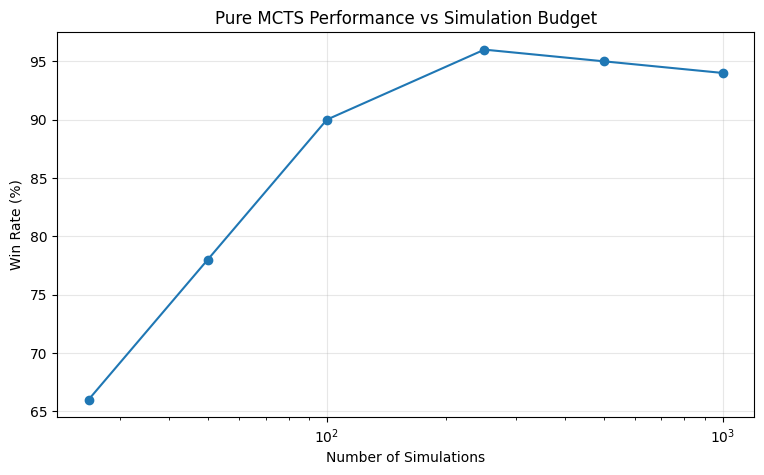

In [79]:
plt.figure(figsize=(9, 5))

plt.plot(
    budget_df["Simulations"],
    budget_df["Win Rate"] * 100,
    marker="o"
)

plt.xscale("log")
plt.xlabel("Number of Simulations")
plt.ylabel("Win Rate (%)")
plt.title("Pure MCTS Performance vs Simulation Budget")
plt.grid(alpha=0.3)

plt.show()

Runtime vs Simulation Budget

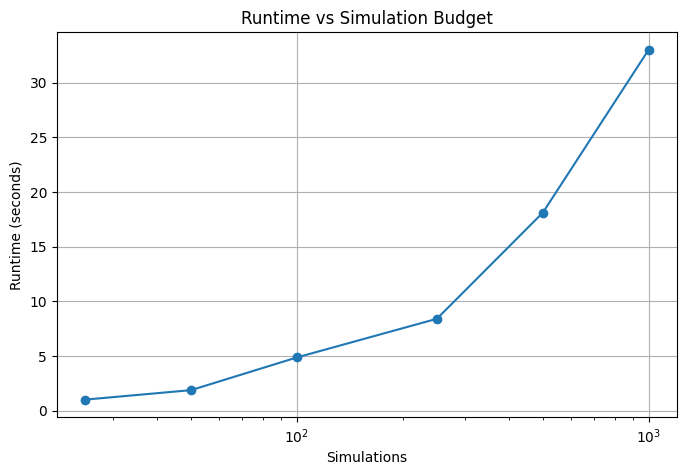

In [80]:
plt.figure(figsize=(8,5))

plt.plot(
    budget_df["Simulations"],
    budget_df["Time"],
    marker="o"
)

plt.xscale("log")

plt.xlabel("Simulations")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs Simulation Budget")

plt.grid(True)

plt.show()

Final Experiment: Baseline vs Optimized

In [81]:
final_results = []

for name, x_agent_fn, game_fn in [
    (
        "Pure MCTS",
        lambda: MCTS(simulations=500),
        play_game
    ),
    (
        "MCTS + Tree Reuse",
        lambda: ReusableAgent(simulations=500),
        play_reusable_game
    )
]:

    wins = draws = losses = 0
    start = time.perf_counter()

    for _ in range(500):

        x = x_agent_fn()
        o = RandomAgent()

        result = game_fn(x, o)

        if result == 1:
            wins += 1
        elif result == 0:
            draws += 1
        else:
            losses += 1

    elapsed = time.perf_counter() - start

    final_results.append({
        "Algorithm": name,
        "Games": 500,
        "Wins": wins,
        "Draws": draws,
        "Losses": losses,
        "Win Rate (%)": wins / 5,
        "Draw Rate (%)": draws / 5,
        "Loss Rate (%)": losses / 5,
        "Runtime (s)": elapsed
    })

final_df = pd.DataFrame(final_results)

final_df

,Algorithm,Games,Wins,Draws,Losses,Win Rate (%),Draw Rate (%),Loss Rate (%),Runtime (s)
0,Pure MCTS,500,468,0,32,93.6,0.0,6.4,86.840132
1,MCTS + Tree Reuse,500,475,0,25,95.0,0.0,5.0,87.758267


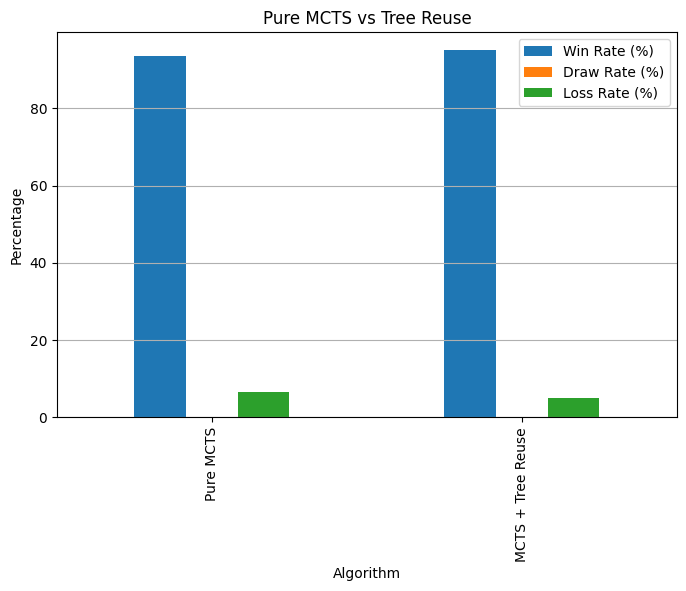

In [82]:
comparison = final_df.set_index("Algorithm")

comparison[["Win Rate (%)","Draw Rate (%)","Loss Rate (%)"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("Pure MCTS vs Tree Reuse")

plt.grid(axis="y")

plt.show()

Save Results

In [83]:
budget_df.to_csv(
    "mcts_simulation_budget_results.csv",
    index=False
)

final_df.to_csv(
    "mcts_final_comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.
